# **Purpose:** Train dictionaries for both signal reconstruction and classification.
# 
**Two types of dictionaries:**
1. **Single global dictionary** for signal compression/reconstruction
2. **Per-class dictionaries** for SRC classification

**Two algorithms compared:**
- MiniBatchDictionaryLearning (fast, stochastic)
    * Mairal et al. (2009) — online stochastic gradient descent.
    * NOT K-SVD. Fast, scales to large datasets.
    * Atom update: coordinate descent on mini-batches (approximate gradient).
- K-SVD (classic, SVD-based)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import os
import numpy as np
import matplotlib.pyplot as plt

from src.config import DATABASE_CONFIGS
from src.dictionary import (
    train_minibatch_dictionary,
    train_ksvd_dictionary,
    train_per_class_dictionaries,
    encode_signals,
    reconstruct_signals,
    compute_reconstruction_metrics
)
from src.visualization import plot_dictionary_atoms, plot_sparse_code_heatmap

## CONFIGURATION

In [2]:
DATABASE = 'DB5'
SUBJECT = 1
LOAD_DIR = f'../data/preprocessed/{DATABASE}/'
SAVE_DIR = LOAD_DIR

config = DATABASE_CONFIGS[DATABASE]
prefix = f'S{SUBJECT:02d}'

# Dictionary parameters
N_ATOMS = 100          # Compression dimension
N_NONZERO = 5          # Sparsity level (k)
ALPHA = 1.0            # Regularization for MiniBatch

print(f"Database: {DATABASE}, Subject: {SUBJECT}")
print(f"Dictionary size: {N_ATOMS} atoms")
print(f"Sparsity: k = {N_NONZERO}")

Database: DB5, Subject: 1
Dictionary size: 100 atoms
Sparsity: k = 5


## 1. Loading preprocessed data

In [3]:
print("\nLoading preprocessed data...")
X_train = np.load(os.path.join(LOAD_DIR, f'{prefix}_X_train.npy'))
y_train = np.load(os.path.join(LOAD_DIR, f'{prefix}_y_train.npy'))
X_test = np.load(os.path.join(LOAD_DIR, f'{prefix}_X_test.npy'))

n_windows, window_samples, n_channels = X_train.shape
signal_dim = window_samples * n_channels

print(f"Train: {X_train.shape}")
print(f"Signal dimension: {signal_dim}")
print(f"Compression ratio: {signal_dim / N_ATOMS:.1f}:1")


Loading preprocessed data...
Train: (7826, 40, 16)
Signal dimension: 640
Compression ratio: 6.4:1


## 1. SINGLE GLOBAL DICTIONARY - For Signal Reconstruction

In [4]:
print("\n" + "="*60)
print("TRAINING SINGLE GLOBAL DICTIONARY (for signal reconstruction)")
print("="*60)

# Train MiniBatch dictionary
print("\n--- MiniBatch Dictionary Learning ---")
dict_mb, atoms_mb = train_minibatch_dictionary(
    X_train,
    n_components=N_ATOMS,
    alpha=ALPHA,
    max_iter=500
)

# Train K-SVD dictionary
print("\n--- K-SVD Dictionary Learning ---")
try:
    dict_ksvd, atoms_ksvd = train_ksvd_dictionary(
        X_train,
        n_components=N_ATOMS,
        transform_n_nonzero_coefs=N_NONZERO,
        max_iter=10
    )
    ksvd_available = True
except ImportError:
    print("K-SVD not available. Skipping.")
    ksvd_available = False

# Save dictionaries
np.save(os.path.join(SAVE_DIR, f'{prefix}_dict_mb_atoms.npy'), atoms_mb)
if ksvd_available:
    np.save(os.path.join(SAVE_DIR, f'{prefix}_dict_ksvd_atoms.npy'), atoms_ksvd)


TRAINING SINGLE GLOBAL DICTIONARY (for signal reconstruction)

--- MiniBatch Dictionary Learning ---
Training MiniBatch Dictionary...
  Samples: 7826
  Signal dimension: 640
  Atoms: 100
  Compression ratio: 6.4:1


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:757: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 72 iterations, alpha=6.810e-03, previous alpha=6.595e-03, with an active set of 67 regressors.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:757: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 86 iterations, alpha=1.228e-02, previous alpha=1.157e-02, with an active set of 87 regressors.
  warnings.warn(



--- K-SVD Dictionary Learning ---
Training K-SVD Dictionary...
  Samples: 7826
  Signal dimension: 640
  Atoms: 100
  Sparsity (k): 5
  Compression ratio: 6.4:1


## Visualize atoms from both dictionaries


Visualizing MiniBatch dictionary atoms...


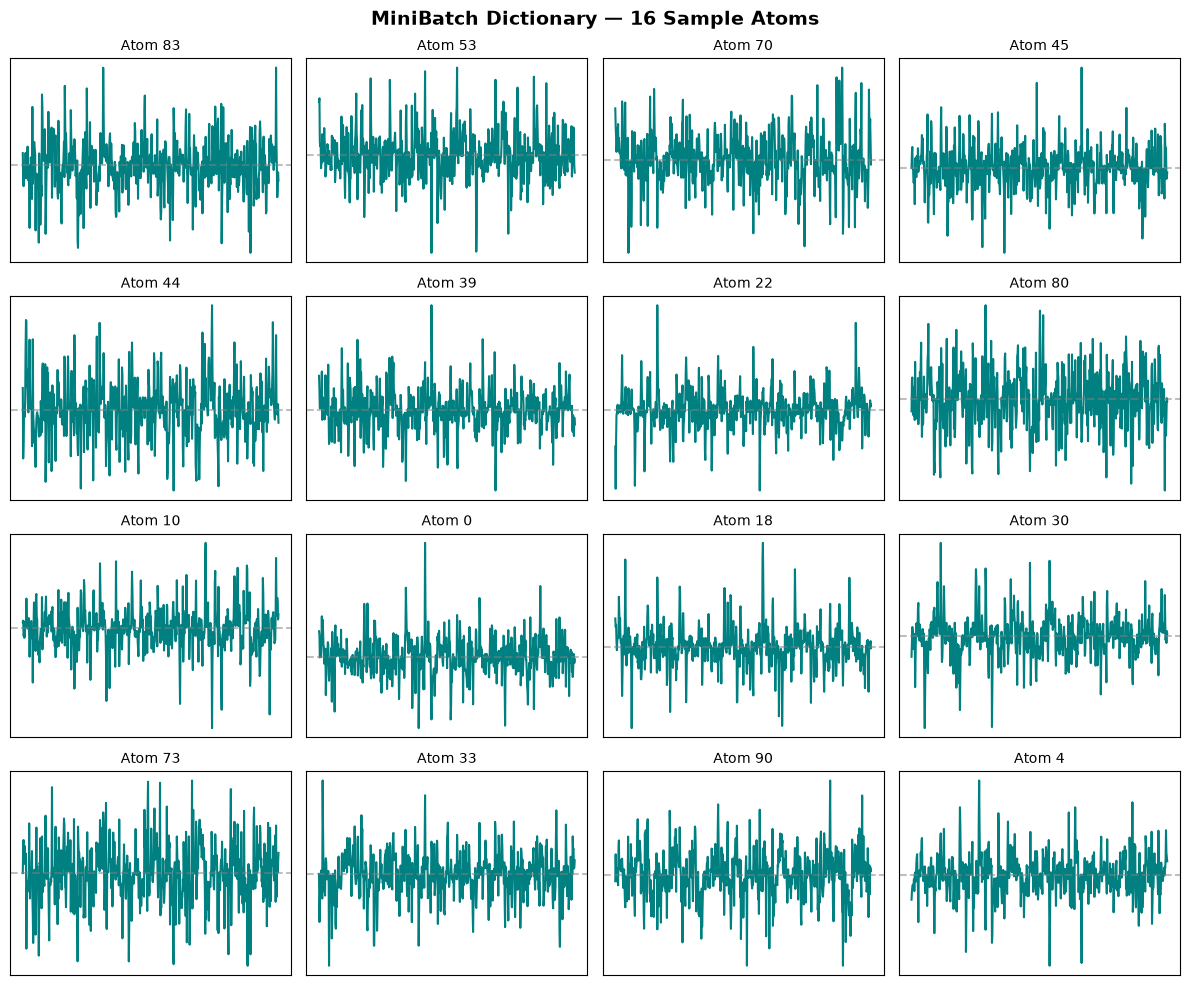

Visualizing K-SVD dictionary atoms...


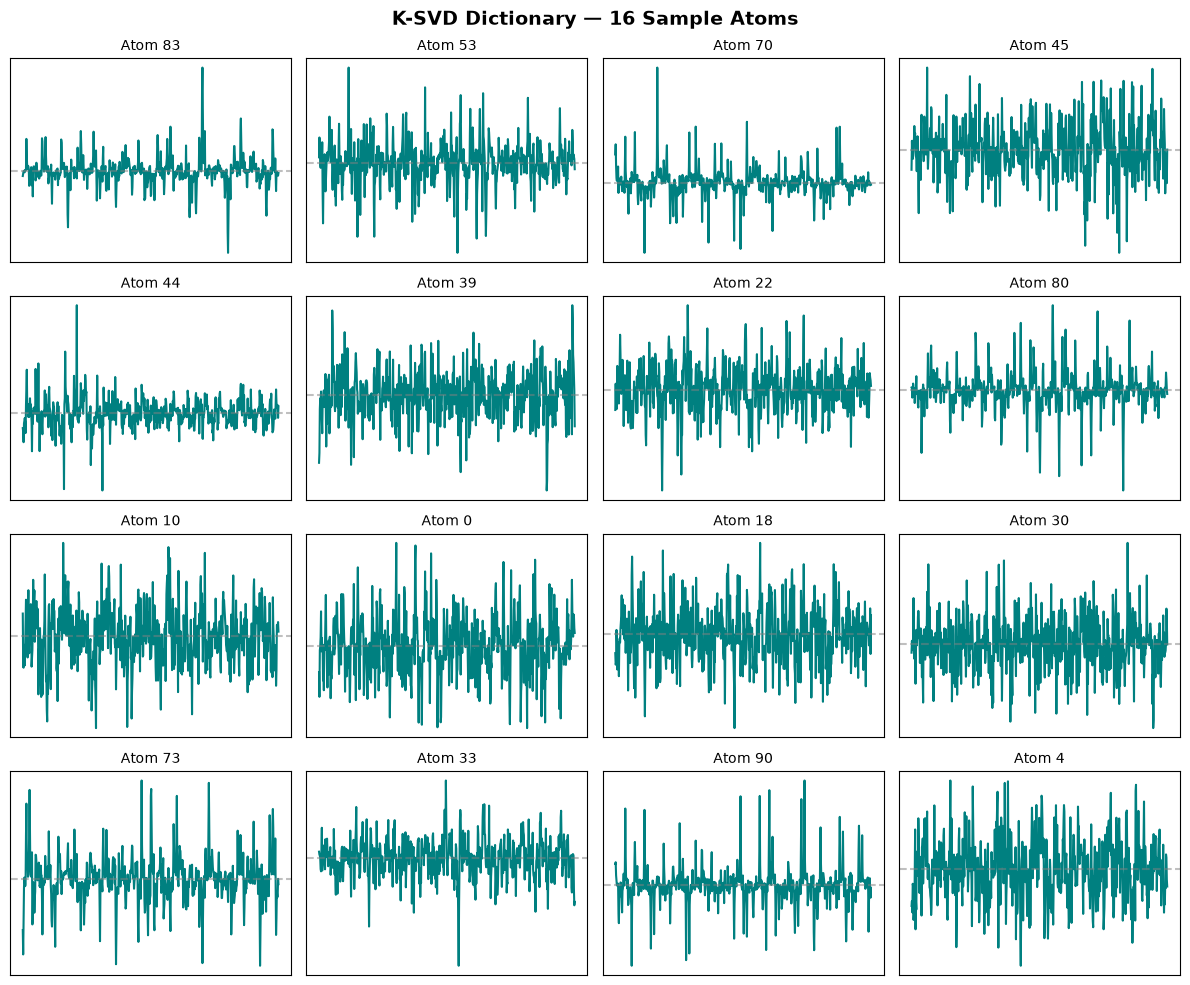

In [5]:
print("\nVisualizing MiniBatch dictionary atoms...")
fig_mb = plot_dictionary_atoms(atoms_mb, n_atoms=16, 
                                title="MiniBatch Dictionary — 16 Sample Atoms")
plt.show()

if ksvd_available:
    print("Visualizing K-SVD dictionary atoms...")
    fig_ksvd = plot_dictionary_atoms(atoms_ksvd, n_atoms=16,
                                      title="K-SVD Dictionary — 16 Sample Atoms")
    plt.show()

## 2. TEST ENCODE-DECODE ON A SAMPLE


TESTING ENCODE-DECODE ON SAMPLE WINDOW
  Encoded 1 windows -> sparse codes shape: (1, 100)
  Average non-zero coefficients: 64.0 (target: 5)

MiniBatch DL:
  Original dimension: 640
  Sparse code dimension: 100
  Non-zero coefficients: 64
  Compression: storing 64 values + indices instead of 640


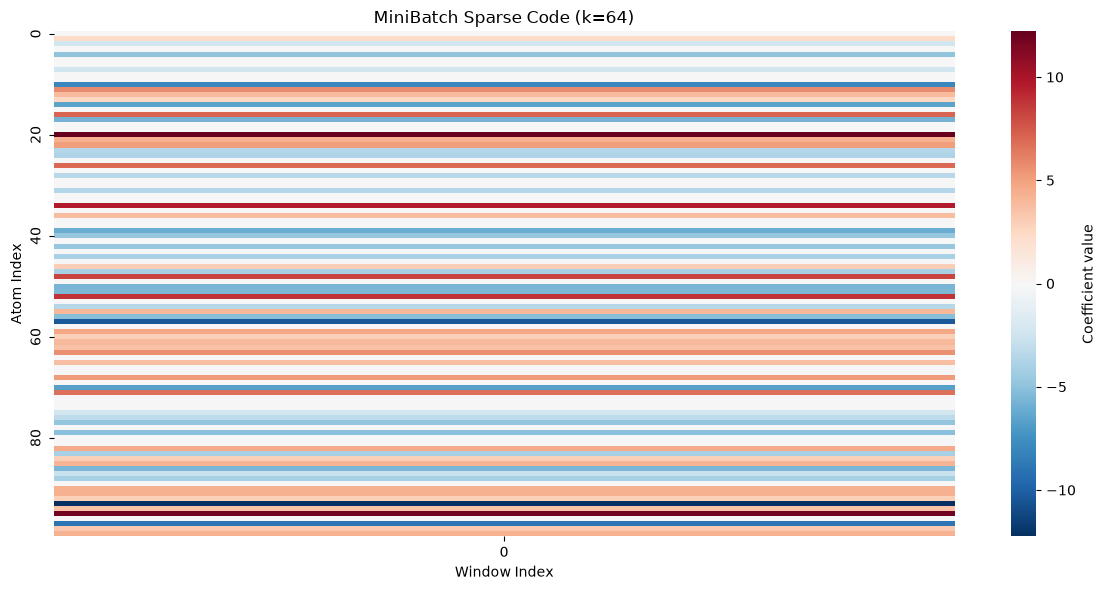

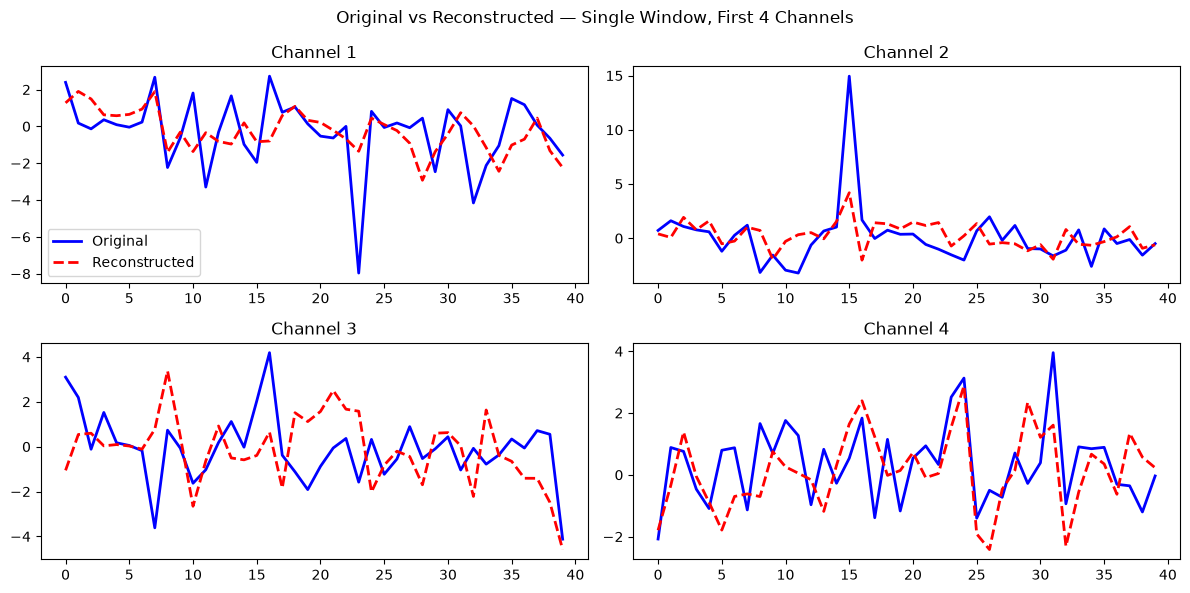

In [6]:
print("\n" + "="*60)
print("TESTING ENCODE-DECODE ON SAMPLE WINDOW")
print("="*60)

# Take a single test window
sample_window = X_test[0:1]  # Keep 3D shape
sample_flat = sample_window.flatten()

# Encode with MiniBatch
sparse_code_mb = encode_signals(sample_window, dict_mb, N_NONZERO)
reconstructed_mb = reconstruct_signals(sparse_code_mb, atoms_mb)

# Show sparsity
n_nonzero_actual = np.sum(sparse_code_mb != 0)
print(f"\nMiniBatch DL:")
print(f"  Original dimension: {len(sample_flat)}")
print(f"  Sparse code dimension: {sparse_code_mb.shape[1]}")
print(f"  Non-zero coefficients: {n_nonzero_actual}")
print(f"  Compression: storing {n_nonzero_actual} values + indices instead of {len(sample_flat)}")

# Visualize sparse code
fig_sparse = plot_sparse_code_heatmap(sparse_code_mb, 
                                       title=f"MiniBatch Sparse Code (k={n_nonzero_actual})")
plt.show()

# Visualize reconstruction
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.plot(sample_flat[i*40:(i+1)*40], 'b-', label='Original', linewidth=2)
    ax.plot(reconstructed_mb[0, i*40:(i+1)*40], 'r--', label='Reconstructed', linewidth=2)
    ax.set_title(f'Channel {i+1}')
    if i == 0:
        ax.legend()
plt.suptitle('Original vs Reconstructed — Single Window, First 4 Channels')
plt.tight_layout()
plt.show()

## 3. PER-CLASS DICTIONARIES — For SRC Classification

In [7]:
print("\n" + "="*60)
print("TRAINING PER-CLASS DICTIONARIES (for SRC classification)")
print("="*60)

per_class_dicts = train_per_class_dictionaries(
    X_train, y_train,
    n_atoms_per_class=30,
    alpha=0.1
)

# Save per-class dictionaries
per_class_atoms = {gid: dico.components_ for gid, dico in per_class_dicts.items()}
np.save(os.path.join(SAVE_DIR, f'{prefix}_per_class_dicts.npy'), per_class_atoms)

print(f"\nTrained dictionaries for {len(per_class_dicts)} gesture classes.")
print("All dictionaries saved to disk.")


TRAINING PER-CLASS DICTIONARIES (for SRC classification)
  Gesture  1:  488 windows ->  30 atoms
  Gesture  2:  417 windows ->  30 atoms
  Gesture  3:  433 windows ->  30 atoms
  Gesture  4:  449 windows ->  30 atoms
  Gesture  5:  431 windows ->  30 atoms
  Gesture  6:  462 windows ->  30 atoms
  Gesture  7:  443 windows ->  30 atoms
  Gesture  8:  446 windows ->  30 atoms
  Gesture  9:  407 windows ->  30 atoms
  Gesture 10:  414 windows ->  30 atoms
  Gesture 11:  454 windows ->  30 atoms
  Gesture 12:  428 windows ->  30 atoms
  Gesture 13:  309 windows ->  30 atoms
  Gesture 14:  303 windows ->  30 atoms


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:757: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 3 iterations, alpha=2.868e-04, previous alpha=2.867e-04, with an active set of 4 regressors.
  warnings.warn(


  Gesture 15:  289 windows ->  30 atoms
  Gesture 16:  337 windows ->  30 atoms
  Gesture 17:  287 windows ->  30 atoms
  Gesture 18:  174 windows ->  30 atoms
  Gesture 19:  160 windows ->  30 atoms
  Gesture 20:  155 windows ->  30 atoms
  Gesture 21:  166 windows ->  30 atoms
  Gesture 22:  180 windows ->  30 atoms
  Gesture 23:  194 windows ->  30 atoms

Trained dictionaries for 23 gesture classes.
All dictionaries saved to disk.
